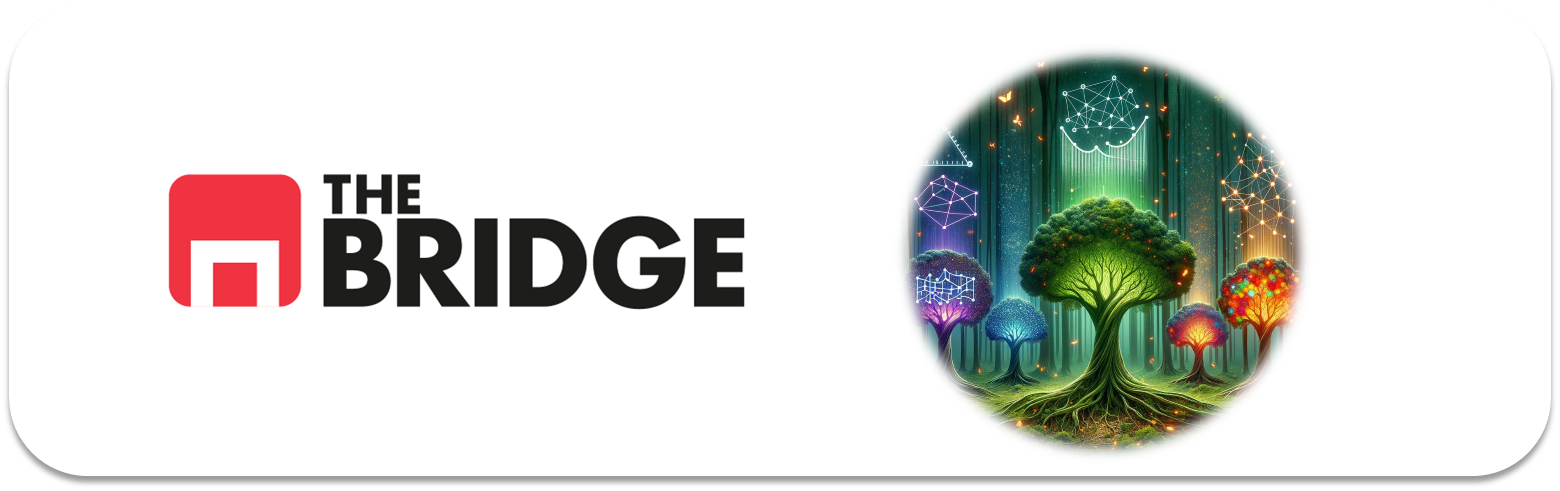

## PRACTICA OBLIGATORIA: **Arboles de Decisión y Ajuste de Hiperparámetros**

* La práctica obligatoria de esta unidad consiste en encontrar el mejor modelo para resolver un problema de predicción de si los destinatarios de una campaña de marketing adquirirán un producto concreto. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import bootcampviztools as bt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import cross_val_score, train_test_split

### Descripción

En el directorio data encontrarás un dataset que contiene datos relacionados con campañas de marketing directo de una institución bancaria portuguesa (es el dataset "Bank Marketing" de la UCI Machine Learning Repository). Los datos se recopilaron de campañas de marketing telefónico, donde el objetivo principal era predecir si el cliente se suscribiría a un depósito a plazo.

La práctica consiste en completar el proceso de creación de un modelo basado en árboles de decisión que permita predecir si un cliente (dadas unas características similares a las del dataset) "comprará" el depósito a plazo. Sigue los pasos necesarios de un proceso de ML para crear el modelo, optimizar sus hiperparámetros, comparar los resultados de esa optimización con una regresión logística (sin optimizar, con sus hiperparámetros por defecto) y finalmente evaluarlo contra test y hacer una pequeña valoración del resultado obtenido.

Tendrás que hacer la limpieza, split, minieda, selección, tratamiento, primeros entrenamientos, optimización, comparación y evaluación según tu mejor criterio. Eso sí, es obligatorio:
- Identificar el target y analizar su distribución
- Realizar una optimización de hiperparámetros, escogiendo un grid medianemante razonado
- Comparar con el modelo baseline
- Evaluar contra test

AYUDA: La dirección del banco nos proporciona estas notas (en inglés):

 
   **bank client data:**  
   1 - age (numeric)  
   2 - job : type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student",
                                       "blue-collar","self-employed","retired","technician","services")   
   3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)  
   4 - education (categorical: "unknown","secondary","primary","tertiary")  
   5 - default: has credit in default? (binary: "yes","no")  
   6 - balance: average yearly balance, in euros (numeric)   
   7 - housing: has housing loan? (binary: "yes","no")  
   8 - loan: has personal loan? (binary: "yes","no")   

   **related with the last contact of the current campaign:**  
   9 - contact: contact communication type (categorical: "unknown","telephone","cellular")   
  10 - day: last contact day of the month (numeric)  
  11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")  
  12 - duration: last contact duration, in seconds (numeric)    

   **other attributes:**  
  13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)  
  14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)  
  15 - previous: number of contacts performed before this campaign and for this client (numeric)  
  16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")

  

## 2. Carga y primera inspección del dataset

In [ ]:

df = pd.read_csv("./data/bank-full.csv", sep=";")

In [3]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
df.shape

(45211, 17)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [6]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


In [9]:
df.describe(include="object").T

,count,unique,top,freq
job,45211,12,blue-collar,9732
marital,45211,3,married,27214
education,45211,4,secondary,23202
default,45211,2,no,44396
housing,45211,2,yes,25130
loan,45211,2,no,37967
contact,45211,3,cellular,29285
month,45211,12,may,13766
poutcome,45211,4,unknown,36959
y,45211,2,no,39922


## 3. Identificación y análisis del target

Identificamos la variable objetivo del problema y analizamos su distribución para conocer la proporción de clientes que contrataron o no el depósito y detectar un posible desbalance entre las clases.

In [ ]:

df["y"].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [14]:
df["y"].value_counts(normalize=True).mul(100).round(2)

y
no     88.3
yes    11.7
Name: proportion, dtype: float64

### Conclusión sobre el target

- La variable objetivo `y` presenta un claro desbalanceo entre sus clases. El 88,30 % de los clientes no contrató el depósito a plazo (`no`), mientras que únicamente el 11,70 % sí lo contrató (`yes`).

- Este desbalanceo deberá tenerse en cuenta durante el modelado y, especialmente, en la evaluación de los modelos, ya que la *accuracy* por sí sola podría resultar engañosa.

### 3.1. Visualización de la distribución del target

Representamos gráficamente la distribución de `y` para visualizar con mayor claridad el desbalance existente entre las clases `no` y `yes`.


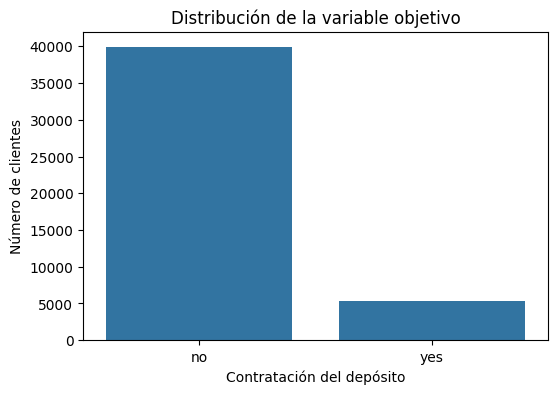

In [ ]:

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="y")

plt.title("Distribución de la variable objetivo")
plt.xlabel("Contratación del depósito")
plt.ylabel("Número de clientes")

plt.show()

## 4. Limpieza de los datos
Revisamos posibles valores problemáticos o especiales del dataset y evaluamos su significado antes de decidir si requieren algún tratamiento.

### 4.1. Revisión de valores `unknown`
Analizamos la presencia de la categoría `unknown` en las variables categóricas para determinar su frecuencia y decidir si debe mantenerse o tratarse antes del modelado.

In [ ]:

(df == "unknown").sum().sort_values(ascending=False)

poutcome     36959
contact      13020
education     1857
job            288
age              0
default          0
balance          0
housing          0
marital          0
loan             0
day              0
duration         0
month            0
campaign         0
pdays            0
previous         0
y                0
dtype: int64

### 4.2. Relación entre `pdays` y `poutcome`
Comprobamos la relación entre ambas variables para entender el significado de sus valores especiales y verificar si son coherentes entre sí.

In [ ]:

pd.crosstab(df["pdays"] == -1, df["poutcome"])

poutcome,failure,other,success,unknown
pdays,,,,
False,4901,1840,1511,5
True,0,0,0,36954


#### Conclusión sobre `pdays` y `poutcome`

- La categoría `unknown` de `poutcome` está estrechamente relacionada con `pdays = -1`. Los 36.954 clientes que no habían sido contactados previamente presentan `poutcome = unknown`.
- Por tanto, estos valores no se tratarán como nulos ni se eliminarán, ya que representan información relevante sobre la ausencia de una campaña previa.

### 4.3. Revisión de `unknown` en `contact`, `education` y `job`

Analizamos la frecuencia de `unknown` en estas variables para valorar su importancia y decidir si requieren algún tratamiento.

In [ ]:

df["contact"].value_counts()

contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

In [20]:
df["contact"].value_counts(normalize=True).mul(100).round(2)

contact
cellular     64.77
unknown      28.80
telephone     6.43
Name: proportion, dtype: float64

### 4.4. Revisión de `unknown` en `education`

Revisamos la distribución de `education` para conocer el peso de la categoría `unknown` respecto al resto de niveles educativos.

In [ ]:

df["education"].value_counts()

education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

In [22]:
df["education"].value_counts(normalize=True).mul(100).round(2)

education
secondary    51.32
tertiary     29.42
primary      15.15
unknown       4.11
Name: proportion, dtype: float64

### 4.5. Revisión de `unknown` en `job`

Analizamos la distribución de `job` para comprobar la frecuencia de la categoría `unknown` frente al resto de ocupaciones.

In [68]:
df["job"].value_counts()

job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

In [24]:
df["job"].value_counts(normalize=True).mul(100).round(2)

job
blue-collar      21.53
management       20.92
technician       16.80
admin.           11.44
services          9.19
retired           5.01
self-employed     3.49
entrepreneur      3.29
unemployed        2.88
housemaid         2.74
student           2.07
unknown           0.64
Name: proportion, dtype: float64

### 4.6. Conclusión sobre los valores `unknown`

Los valores `unknown` aparecen en cuatro variables categóricas: `poutcome`, `contact`, `education` y `job`.

Se ha decidido mantener `unknown` como una categoría válida y no eliminar ni imputar estas observaciones. En `poutcome`, además, se comprobó que la gran mayoría de los valores `unknown` corresponden a clientes que no habían sido contactados previamente (`pdays = -1`), por lo que este valor contiene información relevante.

En `contact`, `education` y `job`, `unknown` también está contemplado explícitamente como una categoría posible en la descripción del dataset. Al no disponer de información que permita asignar de forma fiable otra categoría, se conservará para evitar introducir información artificial o perder observaciones.

### 4.7. Revisión del valor especial `-1` en `pdays`

Analizamos la frecuencia del valor `-1` en `pdays`, que indica que el cliente no había sido contactado previamente, para comprobar su peso en el dataset y decidir cómo tratarlo.

In [ ]:
(df["pdays"] == -1).value_counts()

pdays
True     36954
False     8257
Name: count, dtype: int64

In [26]:
(df["pdays"] == -1).value_counts(normalize=True).mul(100).round(2)

pdays
True     81.74
False    18.26
Name: proportion, dtype: float64

#### Conclusión sobre `pdays`

- El 81,74 % de los clientes presenta `pdays = -1`, lo que según la descripción del dataset indica que no habían sido contactados previamente.

- Por tanto, este valor no se considera un dato nulo o erróneo y se mantendrá, ya que contiene información relevante sobre el historial de contacto del cliente.

### 4.8. Revisión de posibles valores extremos

Revisamos las variables numéricas para identificar valores extremos y valorar si corresponden a observaciones plausibles o si requieren algún tratamiento antes del modelado.

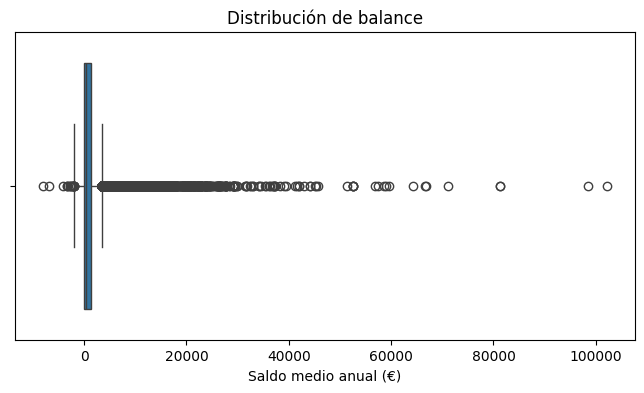

In [ ]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df["balance"])

plt.title("Distribución de balance")
plt.xlabel("Saldo medio anual (€)")

plt.show()

#### Conclusión sobre `balance`

La variable `balance` presenta una distribución muy asimétrica, con numerosos valores extremos, principalmente hacia saldos elevados.

Sin embargo, estos valores son plausibles dentro del contexto bancario y no se consideran necesariamente errores. Por tanto, se mantendrán sin modificar para el modelado con árboles de decisión.

### 4.9. Revisión de valores extremos en duration

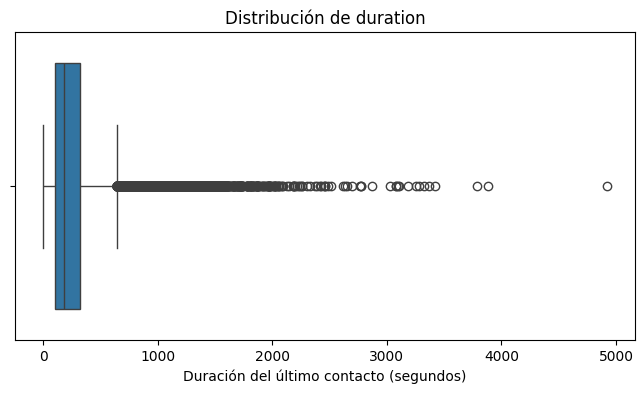

In [ ]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df["duration"])

plt.title("Distribución de duration")
plt.xlabel("Duración del último contacto (segundos)")

plt.show()

#### Conclusión sobre `duration`

La variable `duration` presenta una distribución muy asimétrica hacia la derecha, con numerosos valores extremos. Sin embargo, estos valores son plausibles al representar la duración de las llamadas, por lo que no se eliminarán únicamente por ser considerados outliers.

Además, `duration` requiere especial atención durante la selección de variables, ya que representa la duración del último contacto y esta información solo está disponible una vez realizada la llamada. Dependiendo del momento en el que se quiera realizar la predicción, su utilización podría introducir fuga de información (*data leakage*).

### 4.10. Revisión de valores extremos en `campaign`

Analizamos los valores más altos de `campaign` para comprobar si el número de contactos realizados durante la campaña es plausible y valorar si requiere algún tratamiento.

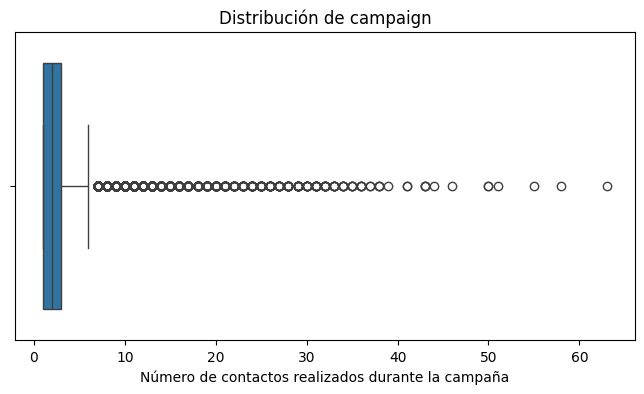

In [ ]:

plt.figure(figsize=(8, 4))

sns.boxplot(x=df["campaign"])

plt.title("Distribución de campaign")
plt.xlabel("Número de contactos realizados durante la campaña")

plt.show()

#### Conclusión sobre `campaign`

La variable `campaign` presenta una distribución asimétrica hacia la derecha. La mayoría de los clientes recibió pocos contactos durante la campaña, aunque existen algunos casos con un número considerablemente mayor de contactos.

Estos valores extremos son plausibles dentro del contexto de la campaña y no existen indicios de que correspondan a errores, por lo que se mantendrán sin modificar.

### 4.11. Revisión de valores extremos en `previous`

Analizamos la distribución de `previous` para identificar posibles valores extremos en el número de contactos realizados antes de la campaña actual.

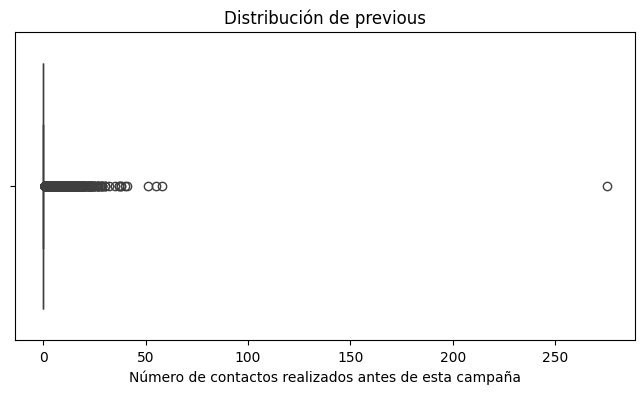

In [ ]:

plt.figure(figsize=(8, 4))

sns.boxplot(x=df["previous"])

plt.title("Distribución de previous")
plt.xlabel("Número de contactos realizados antes de esta campaña")

plt.show()

### 4.12. Inspección de los valores más altos de `previous`

Revisamos los valores más elevados de `previous` y su frecuencia para comprobar si son casos aislados y valorar si corresponden a observaciones plausibles.

In [ ]:
df["previous"].value_counts().sort_index(ascending=False).head(15)

previous
275    1
58     1
55     1
51     1
41     1
40     1
38     2
37     2
35     1
32     1
30     3
29     4
28     2
27     5
26     2
Name: count, dtype: int64

#### Conclusión sobre `previous`

La variable `previous` está fuertemente concentrada en valores bajos, especialmente en 0, debido a que gran parte de los clientes no había sido contactada en campañas anteriores.

Se observan algunos valores elevados y poco frecuentes, incluido un máximo de 275 contactos. Aunque son valores extremos, no existen evidencias suficientes para considerarlos errores, por lo que se mantendrán sin modificar.


## 5. Conclusiones de la limpieza y preparación inicial

Tras la inspección inicial del dataset se han tomado las siguientes decisiones:

- El dataset contiene **45.211 registros y 17 variables**, sin valores nulos ni filas duplicadas.
- Se identificaron valores `"unknown"` en algunas variables categóricas. Estos valores se mantienen, ya que representan una categoría explícita del dataset y no se tratarán como valores nulos.
- En `pdays`, el valor **-1** indica que el cliente no había sido contactado previamente, por lo que se considera un valor válido y se mantiene.
- Las variables numéricas `balance`, `duration`, `campaign` y `previous` presentan distribuciones asimétricas y valores extremos. Al no existir evidencias suficientes para considerarlos errores, se mantienen sin modificar.
- La variable `duration` se tendrá especialmente en cuenta durante la selección de variables, ya que solo está disponible después de realizar el contacto y podría introducir *data leakage* dependiendo del momento en que se realice la predicción.
- No se realizará escalado de las variables para el modelo basado en árboles de decisión, ya que este tipo de algoritmo no lo requiere.

Con estas decisiones se conserva la información original del dataset y se evita realizar transformaciones o eliminaciones que no estén justificadas por el contexto del problema.

## 6. División del dataset en Train y Test

Separamos el dataset en un conjunto de entrenamiento y otro de prueba antes de continuar con el análisis y tratamiento de las variables.

Dado que la variable objetivo `y` presenta un claro desbalance entre sus clases, utilizaremos una división estratificada para conservar aproximadamente la misma proporción de `yes` y `no` en ambos conjuntos.

In [32]:
X = df.drop(columns="y")
y = df["y"]

X.shape, y.shape

((45211, 16), (45211,))

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### 6.1. Comprobación del tamaño de Train y Test

Comprobamos las dimensiones de los conjuntos de entrenamiento y test para verificar que la división de los datos se ha realizado correctamente.

In [ ]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (36168, 16)
X_test: (9043, 16)
y_train: (36168,)
y_test: (9043,)


### 6.2. Comprobación de la distribución del target en Train y Test

Comprobamos que la división estratificada ha mantenido aproximadamente la misma proporción de clases en ambos conjuntos.

In [35]:
distribucion_target = pd.DataFrame({
    "Train (%)": y_train.value_counts(normalize=True).mul(100).round(2),
    "Test (%)": y_test.value_counts(normalize=True).mul(100).round(2)
})

distribucion_target

,Train (%),Test (%)
y,,
no,88.3,88.3
yes,11.7,11.7


#### Conclusión del Train/Test split

La división estratificada ha conservado la distribución original de la variable objetivo en ambos conjuntos: 88,30 % para la clase `no` y 11,70 % para la clase `yes`.

De esta forma, Train y Test mantienen una representación equivalente de ambas clases, algo especialmente importante debido al desbalance existente en el target.

## 7. MiniEDA sobre Train y selección de features

A partir de este punto, el análisis exploratorio se realiza únicamente sobre el conjunto de entrenamiento para evitar utilizar información del conjunto de test durante la selección y preparación del modelo.

El objetivo del MiniEDA será estudiar la relación entre las variables predictoras y el target `y`, con el fin de identificar posibles features relevantes para el modelado.

### 7.1. Identificación de variables numéricas y categóricas

In [36]:
num_features = X_train.select_dtypes(include=np.number).columns.tolist()
cat_features = X_train.select_dtypes(include="object").columns.tolist()

print("Variables numéricas:")
print(num_features)

print("\nVariables categóricas:")
print(cat_features)

Variables numéricas:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Variables categóricas:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


### 7.2. Preparación del conjunto de entrenamiento para el MiniEDA

Creamos un conjunto auxiliar a partir de los datos de entrenamiento incorporando la variable objetivo `y`, que utilizaremos exclusivamente para realizar el MiniEDA.

In [69]:
train_eda = X_train.copy()
train_eda["y"] = y_train

train_eda.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
24001,36,technician,divorced,secondary,no,861,no,no,telephone,29,aug,140,2,-1,0,unknown,no
43409,24,student,single,secondary,no,4126,no,no,cellular,5,apr,907,4,185,7,failure,yes
20669,44,technician,single,secondary,no,244,yes,no,cellular,12,aug,1735,4,-1,0,unknown,yes
18810,48,unemployed,married,secondary,no,0,no,no,telephone,31,jul,35,11,-1,0,unknown,no
23130,38,technician,married,secondary,no,257,no,no,cellular,26,aug,57,10,-1,0,unknown,no


### 7.3. Relación de las variables numéricas con el target

Se analiza la distribución de las variables numéricas en función de la variable objetivo para identificar posibles diferencias entre los clientes que contrataron el depósito (`yes`) y los que no lo contrataron (`no`).

In [70]:
train_eda.groupby("y")[num_features].median().T.round(2)

y,no,yes
age,39.0,38.0
balance,419.0,740.0
day,16.0,15.0
duration,164.0,426.0
campaign,2.0,2.0
pdays,-1.0,-1.0
previous,0.0,0.0


### 7.4. Distribución de las variables numéricas según el target

Para complementar el análisis de las medianas, se representan gráficamente las variables numéricas agrupadas según las clases del target (`y`). Se utiliza la mediana como medida de tendencia central debido a la presencia de distribuciones asimétricas y valores extremos en varias variables.


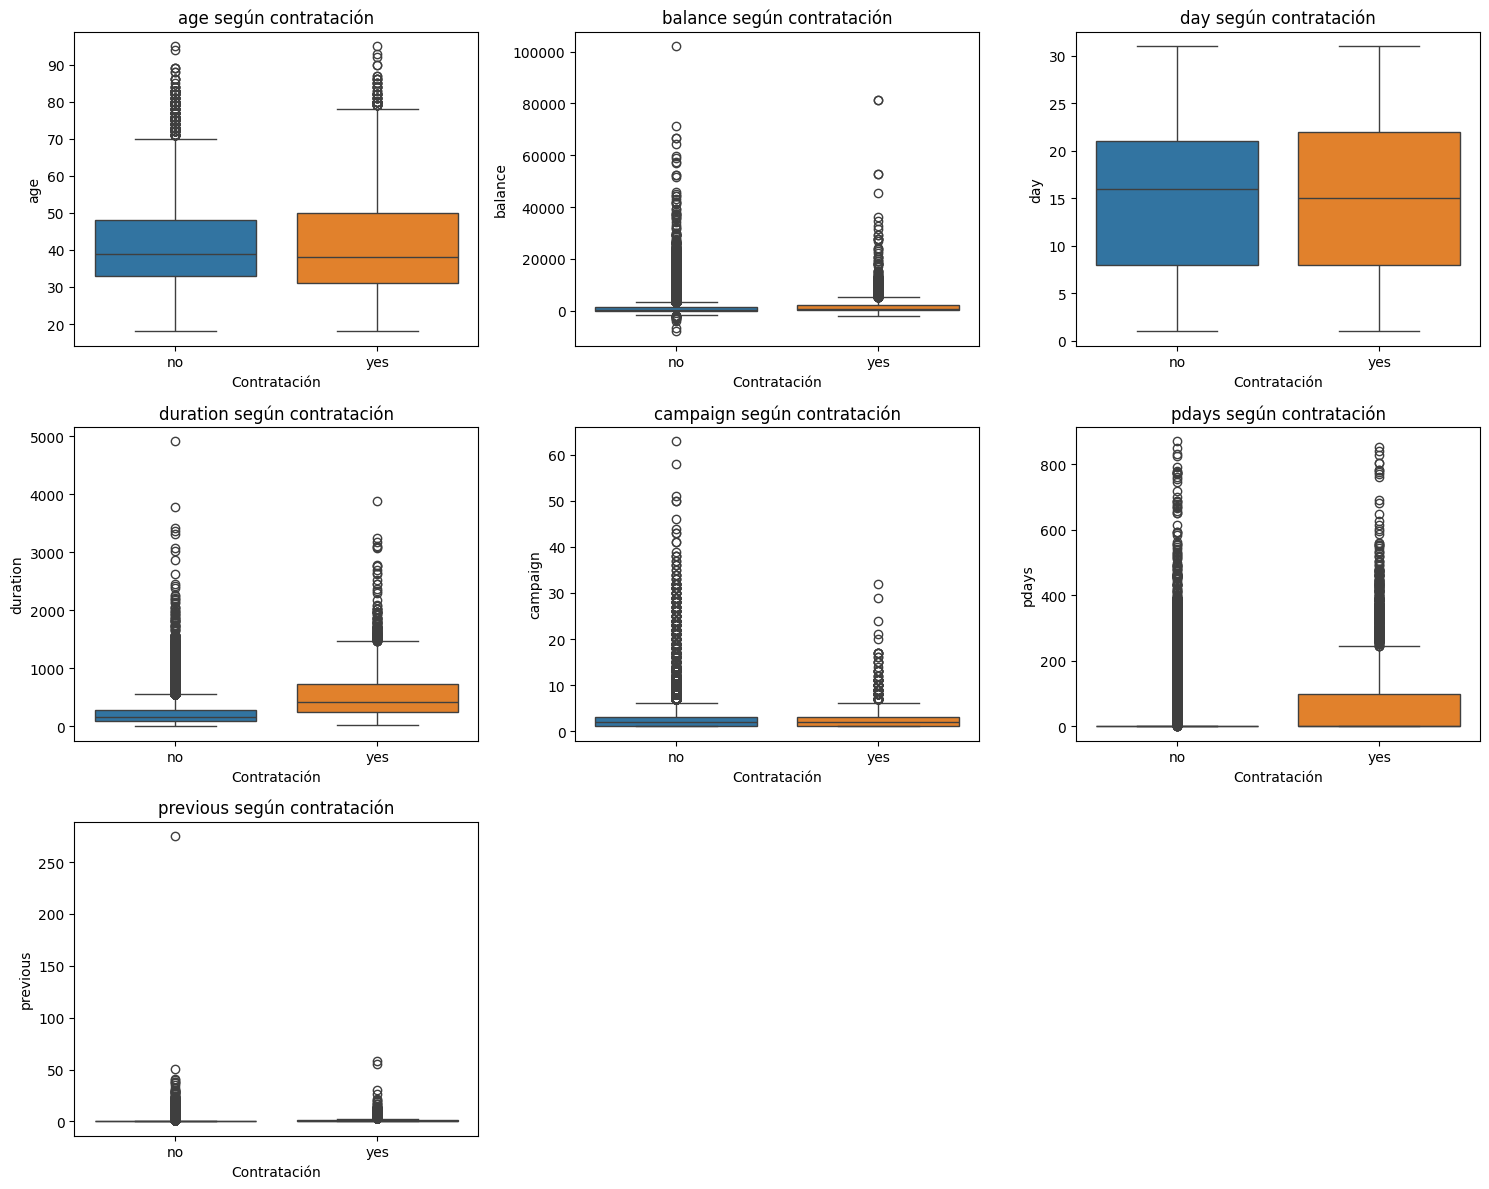

In [65]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, col in zip(axes.flatten(), num_features):

    sns.boxplot(
        data=train_eda,
        x="y",
        y=col,
        hue="y",
        ax=ax,
        legend=False
    )

    ax.set_title(f"{col} según contratación")
    ax.set_xlabel("Contratación")
    ax.set_ylabel(col)

# Ocultamos los ejes que sobran
for ax in axes.flatten()[len(num_features):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

#### Conclusiones del análisis de las variables numéricas

- `duration` presenta la diferencia más clara entre las clases del target: los clientes que contrataron el depósito (`yes`) muestran duraciones de contacto considerablemente mayores.
- `balance` también presenta diferencias entre ambos grupos, aunque con una elevada dispersión y presencia de valores extremos.
- `pdays` muestra diferencias en su distribución que no eran visibles al comparar únicamente las medianas, debido al elevado número de registros con valor `-1`.
- `age`, `day` y `campaign` presentan un mayor solapamiento entre las dos clases, por lo que visualmente parecen tener menor capacidad discriminante de forma individual.
- En `previous`, la concentración de valores próximos a cero y la presencia de valores extremos dificultan apreciar diferencias claras mediante el boxplot.

En conjunto, `duration` destaca como la variable numérica con una relación más evidente con el target, mientras que el resto de variables podrían aportar información adicional al combinarse dentro del modelo.

### 7.5. Relación de las variables categóricas con el target

Se analiza la relación entre las variables categóricas y la variable objetivo `y` mediante frecuencias relativas. De esta forma, se puede comparar la proporción de clientes que contratan (`yes`) o no contratan (`no`) el depósito dentro de cada categoría, independientemente del número de observaciones de cada grupo.

In [71]:
df_cat_eda = train_eda.copy()

df_cat_eda["target_yes"] = (df_cat_eda["y"] == "yes").astype(int)

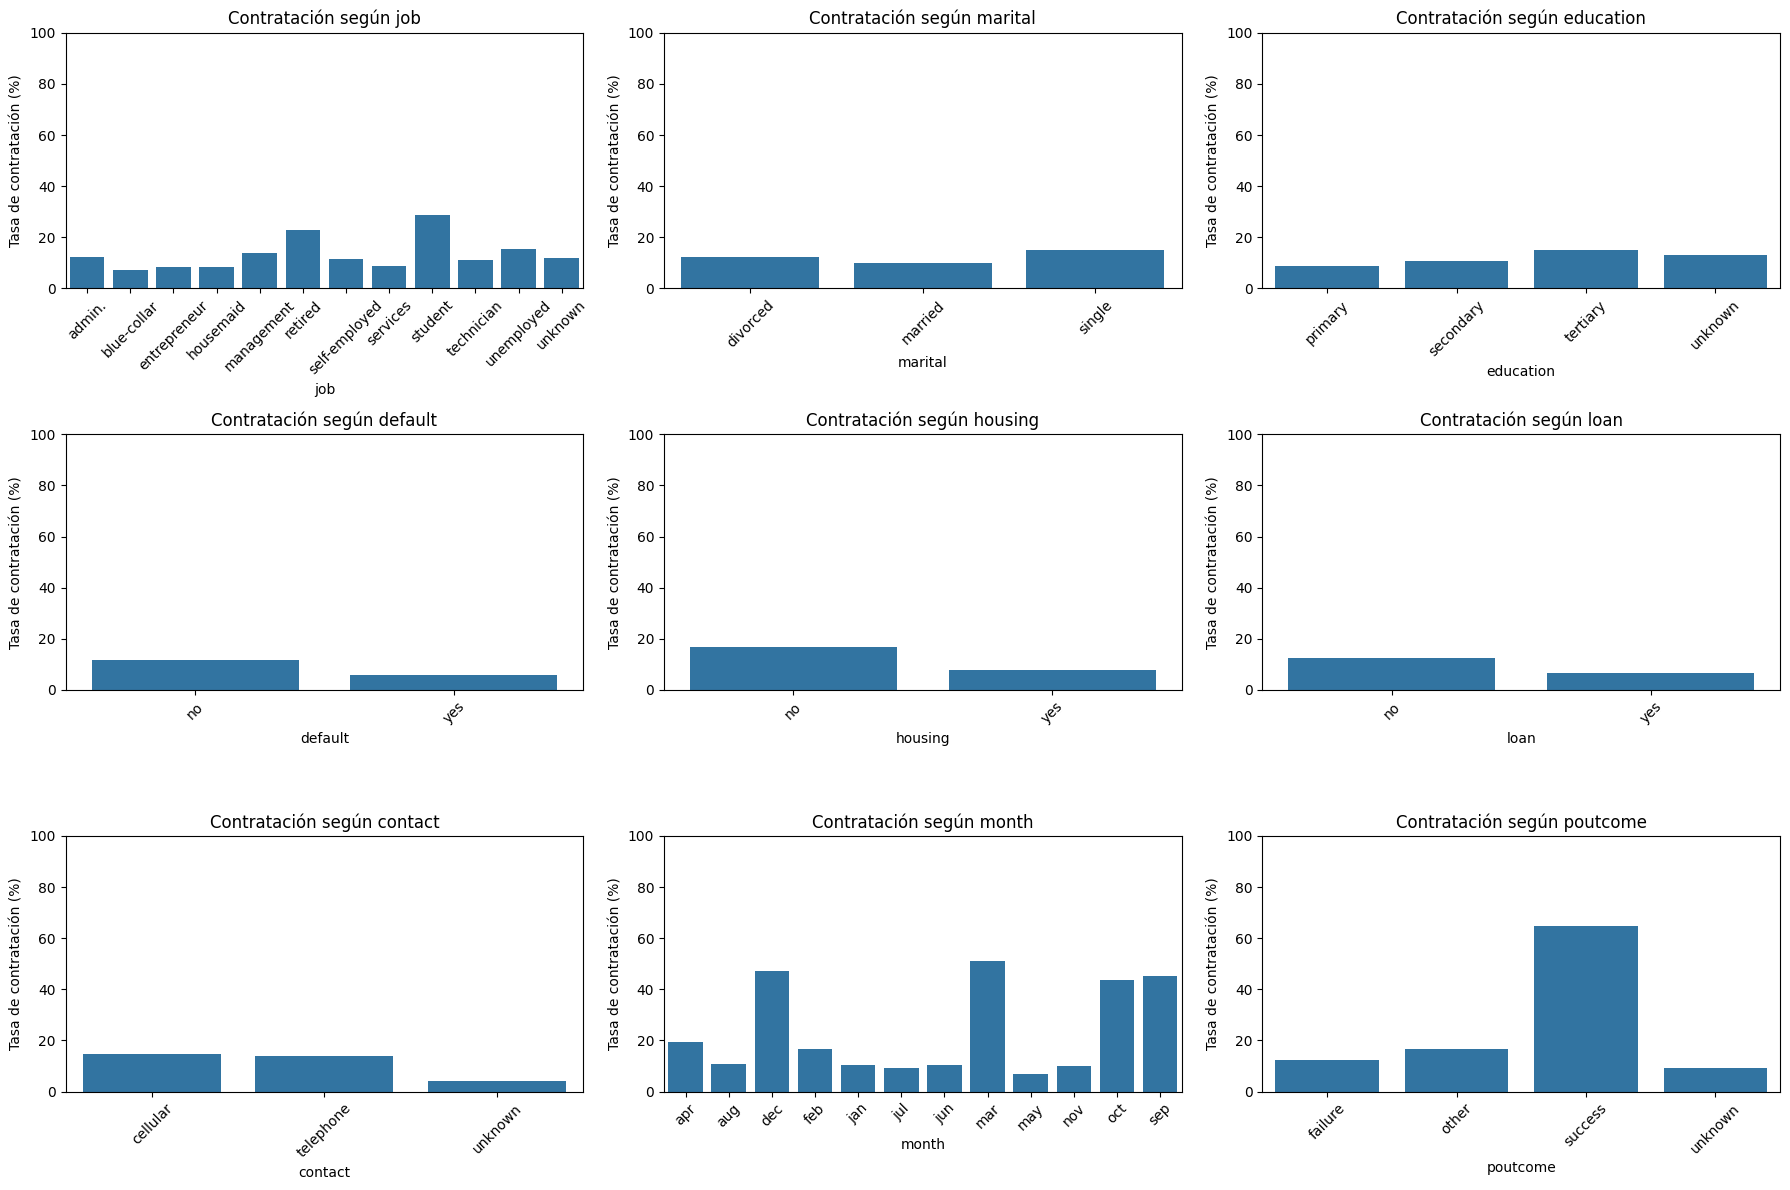

In [72]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

for ax, col in zip(axes.flatten(), cat_features):

    tasa = (
        df_cat_eda.groupby(col)["target_yes"]
        .mean()
        .mul(100)
        .reset_index(name="Tasa_contratacion")
    )

    sns.barplot(
        data=tasa,
        x=col,
        y="Tasa_contratacion",
        ax=ax
    )

    ax.set_title(f"Contratación según {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Tasa de contratación (%)")
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

#### Conclusiones del análisis de las variables categóricas

- `poutcome` presenta diferencias muy marcadas en la tasa de contratación, destacando especialmente los clientes cuyo resultado en la campaña anterior fue `success`.
- `month` también muestra variaciones importantes entre categorías, con determinados meses que presentan tasas de contratación considerablemente superiores.
- `job` presenta diferencias relevantes entre perfiles profesionales, destacando especialmente `student` y `retired`.
- `housing`, `loan` y `contact` muestran diferencias entre sus categorías que podrían aportar información al modelo.
- `marital` y `education` presentan variaciones más moderadas en la tasa de contratación.
- `default` muestra diferencias menos marcadas y parece tener menor capacidad discriminante de forma individual.

En conjunto, varias variables categóricas presentan diferencias en la tasa de contratación, por lo que se mantendrán como potenciales features para las siguientes etapas del modelado.

### 7.6. Selección de potenciales features tras el MiniEDA

A partir del análisis realizado sobre el conjunto de entrenamiento, se identifican las variables que podrían aportar información para predecir la contratación del depósito.

Entre las variables numéricas, `duration` presenta la relación más evidente con el target, mientras que `balance` y `pdays` también muestran diferencias entre las clases. Otras variables como `age`, `day`, `campaign` y `previous` presentan diferencias menos marcadas de forma individual.

Entre las variables categóricas destacan especialmente `poutcome`, `month` y `job`, cuyas categorías muestran diferencias relevantes en las tasas de contratación. Variables como `housing`, `loan` y `contact` también presentan variaciones, mientras que `marital`, `education` y `default` muestran diferencias más moderadas.

Dado que el objetivo del MiniEDA es identificar potenciales predictores y no realizar todavía una selección definitiva, inicialmente se conservarán todas las variables disponibles. La capacidad predictiva conjunta de estas variables se evaluará posteriormente mediante los modelos.

## 8. Tratamiento y preparación de variables para el modelado

A partir de las conclusiones obtenidas en el MiniEDA, preparamos las variables para que puedan ser utilizadas por los modelos de clasificación, aplicando los tratamientos necesarios sobre las variables numéricas y categóricas.

### 8.1. Revisión de `duration` antes del modelado

La variable `duration` representa la duración de la última llamada realizada al cliente y ha mostrado una relación especialmente fuerte con la variable objetivo.

Antes de incorporarla al modelo, es necesario valorar si esta información estaría disponible en el momento en que se realiza la predicción, ya que su uso podría condicionar la aplicabilidad real del modelo.

#### Decisión sobre `duration`

Para esta práctica se mantendrá `duration` como variable predictora, ya que forma parte del conjunto de datos disponible y presenta una relación relevante con el target.

No obstante, debe tenerse en cuenta que esta variable solo se conoce una vez realizada la llamada. Por tanto, en un escenario real cuyo objetivo fuera predecir la contratación antes de contactar con el cliente, `duration` no estaría disponible y debería excluirse del modelo.

Esta limitación se tendrá en cuenta al interpretar posteriormente los resultados.

### 8.2. Tratamiento de `pdays`

La variable `pdays` utiliza el valor `-1` para identificar a los clientes que no habían sido contactados previamente. Al tratarse de información relevante y no de un valor erróneo, se conservará esta información durante la preparación de los datos.

In [74]:
# Creamos una variable que indique si el cliente había sido contactado previamente
X_train["contacted_before"] = (X_train["pdays"] != -1).astype(int)
X_test["contacted_before"] = (X_test["pdays"] != -1).astype(int)

# Comprobamos la distribución en Train
X_train["contacted_before"].value_counts()

contacted_before
0    29584
1     6584
Name: count, dtype: int64

#### Conclusión sobre `contacted_before`

La mayoría de los clientes del conjunto de entrenamiento no había sido contactada previamente. La nueva variable `contacted_before` permite representar explícitamente esta información, diferenciándola del número de días almacenado en `pdays`.

Se mantendrán ambas variables inicialmente y se evaluará posteriormente su utilidad durante el modelado.

### 8.3. Tratamiento de las variables categóricas

Las variables categóricas deben transformarse a formato numérico antes de incorporarlas a los modelos. El tipo de codificación se elegirá teniendo en cuenta el número de categorías y la naturaleza de cada variable.

#### 8.3.1. Codificación de variables categóricas binarias

Las variables `default`, `housing` y `loan` presentan dos categorías (`yes` y `no`), por lo que se transformarán a valores numéricos utilizando `0` para `no` y `1` para `yes`.

In [75]:
# Codificamos las variables binarias: no = 0, yes = 1
binary_features = ["default", "housing", "loan"]

binary_map = {
    "no": 0,
    "yes": 1
}

for col in binary_features:
    X_train[col] = X_train[col].map(binary_map)
    X_test[col] = X_test[col].map(binary_map)

# Comprobamos el resultado
X_train[binary_features].head()

,default,housing,loan
24001,0,0,0
43409,0,0,0
20669,0,1,0
18810,0,0,0
23130,0,0,0


#### 8.3.2. Codificación de `month`

La variable `month` representa el mes en el que se realizó el último contacto con el cliente. Al existir un orden temporal natural entre sus categorías, se transformará a valores numéricos siguiendo el orden de los meses del año.

In [76]:
# Definimos el orden temporal de los meses
month_map = {
    "jan": 1,
    "feb": 2,
    "mar": 3,
    "apr": 4,
    "may": 5,
    "jun": 6,
    "jul": 7,
    "aug": 8,
    "sep": 9,
    "oct": 10,
    "nov": 11,
    "dec": 12
}

# Aplicamos el mismo mapeo a Train y Test
X_train["month"] = X_train["month"].map(month_map)
X_test["month"] = X_test["month"].map(month_map)

# Comprobamos el resultado
X_train["month"].value_counts().sort_index()

month
1      1119
2      2078
3       391
4      2394
5     11062
6      4237
7      5537
8      4986
9       451
10      592
11     3143
12      178
Name: count, dtype: int64

#### 8.3.3. Codificación de las variables categóricas nominales

Las variables `job`, `marital`, `education`, `contact` y `poutcome` contienen categorías sin un orden natural. Por ello, se utilizará One-Hot Encoding para transformarlas en variables numéricas sin establecer relaciones de orden entre sus categorías.

In [77]:
from sklearn.preprocessing import OneHotEncoder

In [79]:
# Variables categóricas nominales
nominal_features = [
    "job",
    "marital",
    "education",
    "contact",
    "poutcome"
]

# Creamos el codificador
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# Ajustamos únicamente con Train
encoder.fit(X_train[nominal_features])

# Transformamos Train y Test
train_encoded = encoder.transform(X_train[nominal_features])
test_encoded = encoder.transform(X_test[nominal_features])

# Convertimos el resultado a DataFrame
train_encoded = pd.DataFrame(
    train_encoded,
    columns=encoder.get_feature_names_out(nominal_features),
    index=X_train.index
)

test_encoded = pd.DataFrame(
    test_encoded,
    columns=encoder.get_feature_names_out(nominal_features),
    index=X_test.index
)

# Comprobamos las dimensiones
print("Train codificado:", train_encoded.shape)
print("Test codificado:", test_encoded.shape)

train_encoded.head()

Train codificado: (36168, 26)
Test codificado: (9043, 26)


,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,education_secondary,education_tertiary,education_unknown,contact_cellular,contact_telephone,contact_unknown,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
24001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
43409,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
20669,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
18810,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
23130,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


#### 8.3.4. Integración de las variables codificadas

Una vez generado el One-Hot Encoding, eliminamos las variables categóricas originales e incorporamos las nuevas columnas codificadas a los conjuntos de Train y Test.

In [81]:
# Eliminamos las variables categóricas originales
X_train = X_train.drop(columns=nominal_features)
X_test = X_test.drop(columns=nominal_features)

# Incorporamos las variables generadas mediante One-Hot Encoding
X_train = pd.concat([X_train, train_encoded], axis=1)
X_test = pd.concat([X_test, test_encoded], axis=1)

# Comprobamos las dimensiones finales
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (36168, 38)
X_test: (9043, 38)


#### 8.3.5. Comprobación final de los tipos de variables

Verificamos que, tras las transformaciones aplicadas, no queden variables categóricas en formato `object` y que los conjuntos de Train y Test mantengan la misma estructura.

In [82]:
print("Columnas object en X_train:")
print(X_train.select_dtypes(include="object").columns.tolist())

print("\nColumnas object en X_test:")
print(X_test.select_dtypes(include="object").columns.tolist())

print("\nMismas columnas en Train y Test:")
print(X_train.columns.equals(X_test.columns))

Columnas object en X_train:
[]

Columnas object en X_test:
[]

Mismas columnas en Train y Test:
True


### 8.4. Tratamiento de las variables numéricas

Tras la codificación de las variables categóricas, se revisan las variables numéricas para determinar si requieren transformaciones antes del modelado. Se tendrán en cuenta las distribuciones observadas durante el MiniEDA y la presencia de asimetrías y valores extremos.

#### 8.4.1. Revisión de la asimetría de las variables numéricas

Calculamos la asimetría de las variables numéricas para complementar lo observado gráficamente durante el MiniEDA y determinar cuáles podrían beneficiarse de una transformación.

In [83]:
# Variables numéricas originales
numeric_features = [
    "age",
    "balance",
    "day",
    "duration",
    "campaign",
    "pdays",
    "previous"
]

# Calculamos la asimetría en Train
X_train[numeric_features].skew().sort_values(ascending=False).round(2)

previous    45.03
balance      8.34
campaign     4.94
duration     3.21
pdays        2.62
age          0.69
day          0.09
dtype: float64

#### Conclusión sobre la asimetría

Los resultados confirman una fuerte asimetría positiva en `previous`, `balance`, `campaign`, `duration` y `pdays`, mientras que `age` y `day` presentan distribuciones considerablemente más equilibradas.

Por tanto, se valorará la transformación de las variables con mayor asimetría antes del escalado, respetando los valores especiales y la naturaleza de cada variable.

#### 8.4.2. Transformación de `duration`, `campaign` y `previous`

Las variables `duration`, `campaign` y `previous` presentan una marcada asimetría positiva. Dado que contienen valores no negativos, aplicamos una transformación logarítmica mediante `log1p` para reducir el efecto de los valores extremos y obtener distribuciones más equilibradas.

In [84]:
# Variables a transformar
log_features = ["duration", "campaign", "previous"]

# Aplicamos la transformación logarítmica en Train y Test
for col in log_features:
    X_train[col] = np.log1p(X_train[col])
    X_test[col] = np.log1p(X_test[col])

# Comprobamos la asimetría después de la transformación
X_train[log_features].skew().sort_values(ascending=False).round(2)

previous    2.54
campaign    1.33
duration   -0.45
dtype: float64

#### Conclusión de la transformación logarítmica

La transformación logarítmica reduce considerablemente la asimetría de las tres variables. La mejora es especialmente notable en `previous`, aunque mantiene cierta asimetría debido a la elevada concentración de valores bajos.

Se mantienen las variables transformadas para continuar con la preparación del modelo.

#### 8.4.3. Tratamiento de `balance`

La variable `balance` presenta una fuerte asimetría y contiene tanto valores positivos como negativos. Por este motivo, no puede aplicarse directamente la misma transformación logarítmica utilizada en las variables anteriores y requiere un tratamiento específico.

In [85]:
# Aplicamos raíz cúbica a balance en Train y Test
X_train["balance"] = np.cbrt(X_train["balance"])
X_test["balance"] = np.cbrt(X_test["balance"])

# Comprobamos la asimetría después de la transformación
print("Asimetría de balance:", round(X_train["balance"].skew(), 2))

Asimetría de balance: -0.08


#### Conclusión sobre `balance`

La transformación mediante raíz cúbica reduce la asimetría de `balance` de 8.34 a -0.08, obteniendo una distribución mucho más equilibrada y conservando el signo de los saldos negativos.

Se mantendrá esta transformación para el modelado.

#### 8.4.4. Tratamiento de `pdays`

La variable `pdays` presenta una distribución asimétrica y contiene el valor especial `-1`, que identifica a los clientes que no habían sido contactados previamente.

Como esta información ya se ha representado explícitamente mediante `contacted_before`, se tratará `pdays` de forma diferenciada para evitar que el valor `-1` se interprete simplemente como una cantidad numérica de días.

##### Transformación de `pdays`

Una vez representada mediante `contacted_before` la ausencia de contactos previos, sustituimos el valor especial `-1` de `pdays` por `0`.

Posteriormente, aplicamos una transformación logarítmica para reducir la asimetría de los valores correspondientes a los clientes que sí habían sido contactados previamente.

In [86]:
# Sustituimos el valor especial -1 por 0
X_train["pdays"] = X_train["pdays"].replace(-1, 0)
X_test["pdays"] = X_test["pdays"].replace(-1, 0)

# Aplicamos transformación logarítmica
X_train["pdays"] = np.log1p(X_train["pdays"])
X_test["pdays"] = np.log1p(X_test["pdays"])

# Comprobamos el resultado
print("Asimetría de pdays:", round(X_train["pdays"].skew(), 2))
print("Valor mínimo:", X_train["pdays"].min())
print("Valor máximo:", round(X_train["pdays"].max(), 2))

Asimetría de pdays: 1.72
Valor mínimo: 0.0
Valor máximo: 6.77


#### Conclusión sobre `pdays`

La transformación reduce la asimetría de `pdays` de 2.62 a 1.72. Los clientes sin contacto previo quedan representados con `pdays = 0`, mientras que esta información se conserva explícitamente mediante la variable `contacted_before`.

Se mantiene esta transformación para el modelado.

### 8.5. Escalado de las variables numéricas

Una vez aplicadas las transformaciones necesarias, se escalan las variables numéricas para situarlas en una escala comparable. Este paso resulta especialmente relevante para modelos sensibles a la magnitud de las variables, como la Regresión Logística.

In [87]:
scale_features = [
    "age",
    "balance",
    "day",
    "duration",
    "campaign",
    "pdays",
    "previous"
]

#### 8.5.1. Estandarización de las variables numéricas

Se utiliza `StandardScaler` para estandarizar las variables numéricas, ajustando el escalador exclusivamente con los datos de Train y aplicando posteriormente la misma transformación sobre Test, evitando así incorporar información del conjunto de prueba durante el entrenamiento.

In [88]:
from sklearn.preprocessing import StandardScaler

# Creamos el escalador
scaler = StandardScaler()

# Ajustamos y transformamos Train
X_train[scale_features] = scaler.fit_transform(
    X_train[scale_features]
)

# Aplicamos a Test la transformación aprendida en Train
X_test[scale_features] = scaler.transform(
    X_test[scale_features]
)

# Comprobamos el resultado
X_train[scale_features].describe().round(2)

,age,balance,day,duration,campaign,pdays,previous
count,36168.00,36168.00,36168.00,36168.00,36168.00,36168.00,36168.00
mean,-0.00,-0.00,0.00,-0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.15,-4.18,-1.78,-5.60,-0.91,-0.47,-0.42
25%,-0.74,-0.50,-0.94,-0.57,-0.91,-0.47,-0.42
50%,-0.18,0.03,0.02,0.03,-0.12,-0.47,-0.42
75%,0.67,0.58,0.62,0.64,0.45,-0.47,-0.42
max,5.09,5.97,1.82,3.61,5.86,2.84,10.12


#### Conclusión del escalado

Tras aplicar `StandardScaler`, las variables numéricas presentan una media próxima a 0 y una desviación estándar próxima a 1, confirmando que la estandarización se ha realizado correctamente.


### 8.6. Comprobación final de los datos preparados

Antes de iniciar el modelado, verificamos que los conjuntos de entrenamiento y prueba mantengan dimensiones coherentes, no contengan valores nulos y estén formados únicamente por variables numéricas.

In [89]:
print("Dimensiones:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nValores nulos:")
print("X_train:", X_train.isnull().sum().sum())
print("X_test:", X_test.isnull().sum().sum())

print("\nColumnas object:")
print("X_train:", X_train.select_dtypes(include="object").columns.tolist())
print("X_test:", X_test.select_dtypes(include="object").columns.tolist())

print("\nMismas columnas en Train y Test:")
print(X_train.columns.equals(X_test.columns))

Dimensiones:
X_train: (36168, 38)
X_test: (9043, 38)
y_train: (36168,)
y_test: (9043,)

Valores nulos:
X_train: 0
X_test: 0

Columnas object:
X_train: []
X_test: []

Mismas columnas en Train y Test:
True


#### Conclusión de la preparación de los datos

Tras las transformaciones realizadas, los conjuntos de Train y Test presentan una estructura consistente, sin valores nulos y con todas las variables en formato numérico.

Ambos conjuntos contienen las mismas 38 variables predictoras y se encuentran preparados para iniciar la fase de modelado.

## 9. Modelado

Una vez finalizada la preparación de los datos, se inicia la fase de modelado. Se entrenarán y evaluarán distintos modelos de clasificación con el objetivo de predecir si un cliente contratará el depósito (`yes`) o no (`no`).

Dado el desbalance observado en la variable objetivo, la evaluación no se limitará únicamente al `accuracy`, sino que se tendrán en cuenta métricas como `precision`, `recall`, `F1-score` y ROC-AUC.

### 9.1. Modelo base: Regresión Logística

Se utiliza una Regresión Logística como primer modelo de clasificación. Este modelo servirá como referencia para evaluar posteriormente si modelos más complejos consiguen mejorar la capacidad predictiva.

#### 9.1.1. Codificación de la variable objetivo

La variable objetivo se transforma a formato numérico, asignando `0` a la clase `no` y `1` a la clase `yes`. De esta forma, la clase positiva (`1`) representa a los clientes que contrataron el depósito.

In [90]:
# Codificamos la variable objetivo
target_map = {
    "no": 0,
    "yes": 1
}

y_train = y_train.map(target_map)
y_test = y_test.map(target_map)

# Comprobamos el resultado
print("Train:")
print(y_train.value_counts())

print("\nTest:")
print(y_test.value_counts())

Train:
y
0    31937
1     4231
Name: count, dtype: int64

Test:
y
0    7985
1    1058
Name: count, dtype: int64


#### 9.1.2. Entrenamiento de la Regresión Logística

Se entrena un primer modelo de Regresión Logística utilizando los datos preparados. Este modelo se utilizará como referencia inicial para evaluar el rendimiento de los modelos posteriores.

In [91]:
from sklearn.linear_model import LogisticRegression

# Creamos el modelo
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Entrenamos el modelo
log_reg.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

#### 9.1.3. Predicciones sobre Train y Test

Una vez entrenado el modelo, realizamos predicciones sobre los conjuntos de entrenamiento y prueba para evaluar posteriormente su comportamiento y capacidad de generalización.

In [92]:
# Predicciones
y_train_pred = log_reg.predict(X_train)
y_test_pred = log_reg.predict(X_test)

# Comprobamos las primeras predicciones
print("Predicciones Train:", y_train_pred[:10])
print("Predicciones Test:", y_test_pred[:10])

Predicciones Train: [0 1 1 0 0 1 0 0 0 0]
Predicciones Test: [0 0 0 0 0 0 0 1 0 0]


#### 9.1.4. Evaluación de la Regresión Logística

Evaluamos el rendimiento del modelo tanto en Train como en Test mediante distintas métricas de clasificación. Dado el desbalance de la variable objetivo, además del `accuracy` se analizan `precision`, `recall`, `F1-score` y ROC-AUC, prestando especial atención a la clase positiva (`1`), que representa la contratación del depósito.

In [93]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Probabilidades de la clase positiva
y_train_proba = log_reg.predict_proba(X_train)[:, 1]
y_test_proba = log_reg.predict_proba(X_test)[:, 1]

# Métricas de Train
metrics_train = {
    "Accuracy": accuracy_score(y_train, y_train_pred),
    "Precision": precision_score(y_train, y_train_pred),
    "Recall": recall_score(y_train, y_train_pred),
    "F1-score": f1_score(y_train, y_train_pred),
    "ROC-AUC": roc_auc_score(y_train, y_train_proba)
}

# Métricas de Test
metrics_test = {
    "Accuracy": accuracy_score(y_test, y_test_pred),
    "Precision": precision_score(y_test, y_test_pred),
    "Recall": recall_score(y_test, y_test_pred),
    "F1-score": f1_score(y_test, y_test_pred),
    "ROC-AUC": roc_auc_score(y_test, y_test_proba)
}

# Tabla comparativa
metrics_df = pd.DataFrame({
    "Train": metrics_train,
    "Test": metrics_test
}).round(3)

metrics_df

,Train,Test
Accuracy,0.900,0.899
Precision,0.639,0.635
Recall,0.328,0.323
F1-score,0.433,0.428
ROC-AUC,0.895,0.892


#### Conclusión sobre la Regresión Logística

La Regresión Logística presenta resultados muy similares entre Train y Test, sin indicios relevantes de sobreajuste. El modelo alcanza un ROC-AUC de 0.892 en Test, mostrando una buena capacidad general para diferenciar entre ambas clases.

Sin embargo, aunque el `accuracy` es elevado (0.899), debe interpretarse con cautela debido al desbalance de la variable objetivo. El principal punto débil se encuentra en el `recall` de la clase positiva (0.323), lo que indica que el modelo identifica únicamente una parte de los clientes que finalmente contratan el depósito.

Por tanto, este modelo se utilizará como referencia para comparar posteriormente otras alternativas de clasificación.

#### 9.1.5. Matriz de confusión

Analizamos la matriz de confusión sobre el conjunto de Test para observar cómo se distribuyen los aciertos y errores del modelo entre las clases `no` y `yes`.

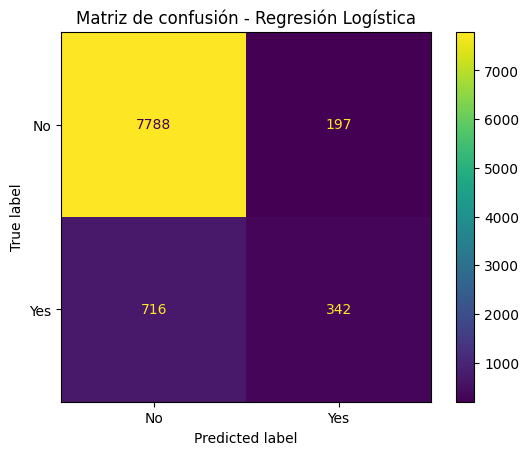

In [94]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculamos la matriz de confusión sobre Test
cm = confusion_matrix(y_test, y_test_pred)

# Visualizamos la matriz
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
)

disp.plot()
plt.title("Matriz de confusión - Regresión Logística")
plt.show()

#### Conclusión de la matriz de confusión

La matriz de confusión confirma que la Regresión Logística identifica correctamente la mayoría de los clientes que no contratan el depósito, con 7.788 verdaderos negativos y únicamente 197 falsos positivos.

Sin embargo, presenta mayor dificultad para detectar la clase positiva: de los 1.058 clientes que realmente contrataron, identifica correctamente 342 y clasifica erróneamente 716 como `no`.

Este resultado es coherente con el bajo `recall` obtenido para la clase positiva (0.323) y evidencia que, con el umbral de clasificación actual, el modelo deja sin identificar una parte importante de los clientes que finalmente contratan.

### 9.2. Árbol de Decisión

Como segundo modelo se utiliza un Árbol de Decisión, capaz de capturar relaciones no lineales e interacciones entre las variables sin asumir una relación lineal con la variable objetivo.

Su rendimiento se comparará con la Regresión Logística utilizada como modelo de referencia.

#### 9.2.1. Entrenamiento del Árbol de Decisión

Se entrena inicialmente el modelo con sus parámetros básicos para obtener una primera referencia de su comportamiento antes de realizar posibles ajustes.

In [95]:
from sklearn.tree import DecisionTreeClassifier

# Creamos el modelo
decision_tree = DecisionTreeClassifier(
    random_state=42
)

# Entrenamos el modelo
decision_tree.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

#### 9.2.2. Predicciones sobre Train y Test

In [96]:
# Predicciones
y_train_pred_tree = decision_tree.predict(X_train)
y_test_pred_tree = decision_tree.predict(X_test)

# Comprobamos las primeras predicciones
print("Predicciones Train:", y_train_pred_tree[:10])
print("Predicciones Test:", y_test_pred_tree[:10])

Predicciones Train: [0 1 1 0 0 0 0 0 0 0]
Predicciones Test: [0 0 0 0 0 0 0 1 0 0]


#### 9.2.3. Evaluación del Árbol de Decisión

Se evalúa el rendimiento del Árbol de Decisión utilizando las mismas métricas empleadas en la Regresión Logística. La comparación entre Train y Test permitirá analizar tanto su capacidad predictiva como la posible presencia de sobreajuste.

In [97]:
# Probabilidades de la clase positiva
y_train_proba_tree = decision_tree.predict_proba(X_train)[:, 1]
y_test_proba_tree = decision_tree.predict_proba(X_test)[:, 1]

# Métricas de Train
metrics_train_tree = {
    "Accuracy": accuracy_score(y_train, y_train_pred_tree),
    "Precision": precision_score(y_train, y_train_pred_tree),
    "Recall": recall_score(y_train, y_train_pred_tree),
    "F1-score": f1_score(y_train, y_train_pred_tree),
    "ROC-AUC": roc_auc_score(y_train, y_train_proba_tree)
}

# Métricas de Test
metrics_test_tree = {
    "Accuracy": accuracy_score(y_test, y_test_pred_tree),
    "Precision": precision_score(y_test, y_test_pred_tree),
    "Recall": recall_score(y_test, y_test_pred_tree),
    "F1-score": f1_score(y_test, y_test_pred_tree),
    "ROC-AUC": roc_auc_score(y_test, y_test_proba_tree)
}

# Tabla comparativa
metrics_tree_df = pd.DataFrame({
    "Train": metrics_train_tree,
    "Test": metrics_test_tree
}).round(3)

metrics_tree_df

,Train,Test
Accuracy,1.0,0.876
Precision,1.0,0.468
Recall,1.0,0.469
F1-score,1.0,0.469
ROC-AUC,1.0,0.699


#### Conclusión sobre el Árbol de Decisión

El Árbol de Decisión alcanza un rendimiento perfecto en el conjunto de entrenamiento, con valores de 1.000 en todas las métricas. Sin embargo, su rendimiento disminuye considerablemente en Test, especialmente en `precision`, `F1-score` y ROC-AUC.

Esta diferencia entre Train y Test evidencia un claro sobreajuste: el árbol sin restricciones se adapta excesivamente a los datos de entrenamiento y pierde capacidad de generalización ante nuevos datos.

Aunque consigue un `recall` superior al de la Regresión Logística en Test, será necesario regularizar el árbol para reducir el sobreajuste y buscar un mejor equilibrio entre las métricas.

### 9.3. Regularización del Árbol de Decisión

Dado el claro sobreajuste observado en el árbol inicial, se ajustará su complejidad mediante algunos de sus hiperparámetros con el objetivo de mejorar la capacidad de generalización del modelo.

#### 9.3.1. Búsqueda de hiperparámetros mediante Grid Search

Para reducir el sobreajuste del Árbol de Decisión, se realiza una búsqueda de hiperparámetros mediante `GridSearchCV`. La selección se realiza utilizando validación cruzada únicamente sobre el conjunto de entrenamiento.

Se utiliza ROC-AUC como métrica de optimización, ya que permite evaluar la capacidad del modelo para discriminar entre ambas clases sin depender de un único umbral de clasificación.

In [98]:
from sklearn.model_selection import GridSearchCV

# Espacio de hiperparámetros
param_grid = {
    "max_depth": [3, 5, 7, 10, 15],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10]
}

# Modelo base
tree_grid = DecisionTreeClassifier(
    random_state=42
)

# Grid Search con validación cruzada
grid_search_tree = GridSearchCV(
    estimator=tree_grid,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

# Ajustamos únicamente con Train
grid_search_tree.fit(X_train, y_train)

print("Mejores hiperparámetros:")
print(grid_search_tree.best_params_)

print("\nMejor ROC-AUC medio en validación cruzada:")
print(round(grid_search_tree.best_score_, 3))

Mejores hiperparámetros:
{'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 2}

Mejor ROC-AUC medio en validación cruzada:
0.885


#### 9.3.2. Evaluación del Árbol de Decisión regularizado

Una vez identificada la mejor combinación de hiperparámetros mediante validación cruzada, se evalúa el árbol regularizado sobre Train y Test para comprobar si se ha reducido el sobreajuste observado en el modelo inicial.

In [99]:
# Recuperamos el mejor modelo obtenido mediante Grid Search
decision_tree_reg = grid_search_tree.best_estimator_

# Predicciones
y_train_pred_tree_reg = decision_tree_reg.predict(X_train)
y_test_pred_tree_reg = decision_tree_reg.predict(X_test)

# Probabilidades de la clase positiva
y_train_proba_tree_reg = decision_tree_reg.predict_proba(X_train)[:, 1]
y_test_proba_tree_reg = decision_tree_reg.predict_proba(X_test)[:, 1]

# Métricas de Train
metrics_train_tree_reg = {
    "Accuracy": accuracy_score(y_train, y_train_pred_tree_reg),
    "Precision": precision_score(y_train, y_train_pred_tree_reg),
    "Recall": recall_score(y_train, y_train_pred_tree_reg),
    "F1-score": f1_score(y_train, y_train_pred_tree_reg),
    "ROC-AUC": roc_auc_score(y_train, y_train_proba_tree_reg)
}

# Métricas de Test
metrics_test_tree_reg = {
    "Accuracy": accuracy_score(y_test, y_test_pred_tree_reg),
    "Precision": precision_score(y_test, y_test_pred_tree_reg),
    "Recall": recall_score(y_test, y_test_pred_tree_reg),
    "F1-score": f1_score(y_test, y_test_pred_tree_reg),
    "ROC-AUC": roc_auc_score(y_test, y_test_proba_tree_reg)
}

# Tabla comparativa
metrics_tree_reg_df = pd.DataFrame({
    "Train": metrics_train_tree_reg,
    "Test": metrics_test_tree_reg
}).round(3)

metrics_tree_reg_df

,Train,Test
Accuracy,0.920,0.899
Precision,0.702,0.590
Recall,0.552,0.443
F1-score,0.618,0.506
ROC-AUC,0.936,0.888


#### Conclusión del Árbol de Decisión regularizado

La regularización mejora considerablemente la capacidad de generalización del Árbol de Decisión. Frente al modelo inicial, el ROC-AUC en Test aumenta de 0.699 a 0.888 y también mejoran `accuracy`, `precision` y `F1-score`.

Aunque el rendimiento en Train continúa siendo superior al de Test, la diferencia se reduce notablemente respecto al árbol sin restricciones, disminuyendo así el problema de sobreajuste.

El `recall` en Test se sitúa en 0.443, ligeramente por debajo del árbol inicial, pero superior al obtenido con la Regresión Logística. En conjunto, el árbol regularizado ofrece un comportamiento mucho más equilibrado que el modelo original.

### 9.4. Random Forest

Como siguiente modelo se utiliza Random Forest, un método de ensamblado que combina múltiples árboles de decisión. Al agregar las predicciones de distintos árboles, busca mejorar la capacidad de generalización y reducir el sobreajuste asociado a un único Árbol de Decisión.

#### 9.4.1. Entrenamiento del Random Forest

Se entrena inicialmente un modelo Random Forest con una configuración básica para obtener una primera referencia de su rendimiento antes de realizar posibles ajustes de hiperparámetros.

In [100]:
from sklearn.ensemble import RandomForestClassifier

# Creamos el modelo
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Entrenamos el modelo
random_forest.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

#### 9.4.2. Predicciones sobre Train y Test

In [101]:
# Predicciones
y_train_pred_rf = random_forest.predict(X_train)
y_test_pred_rf = random_forest.predict(X_test)

# Comprobamos las primeras predicciones
print("Predicciones Train:", y_train_pred_rf[:10])
print("Predicciones Test:", y_test_pred_rf[:10])

Predicciones Train: [0 1 1 0 0 0 0 0 0 0]
Predicciones Test: [0 0 0 0 0 0 0 1 0 0]


#### 9.4.3. Evaluación del Random Forest

Se evalúa el rendimiento del Random Forest utilizando las mismas métricas empleadas en los modelos anteriores. La comparación entre Train y Test permitirá analizar su capacidad de generalización y detectar una posible presencia de sobreajuste.

In [102]:
# Probabilidades de la clase positiva
y_train_proba_rf = random_forest.predict_proba(X_train)[:, 1]
y_test_proba_rf = random_forest.predict_proba(X_test)[:, 1]

# Métricas de Train
metrics_train_rf = {
    "Accuracy": accuracy_score(y_train, y_train_pred_rf),
    "Precision": precision_score(y_train, y_train_pred_rf),
    "Recall": recall_score(y_train, y_train_pred_rf),
    "F1-score": f1_score(y_train, y_train_pred_rf),
    "ROC-AUC": roc_auc_score(y_train, y_train_proba_rf)
}

# Métricas de Test
metrics_test_rf = {
    "Accuracy": accuracy_score(y_test, y_test_pred_rf),
    "Precision": precision_score(y_test, y_test_pred_rf),
    "Recall": recall_score(y_test, y_test_pred_rf),
    "F1-score": f1_score(y_test, y_test_pred_rf),
    "ROC-AUC": roc_auc_score(y_test, y_test_proba_rf)
}

# Tabla comparativa
metrics_rf_df = pd.DataFrame({
    "Train": metrics_train_rf,
    "Test": metrics_test_rf
}).round(3)

metrics_rf_df

,Train,Test
Accuracy,1.0,0.905
Precision,1.0,0.671
Recall,1.0,0.370
F1-score,1.0,0.477
ROC-AUC,1.0,0.926


#### Conclusión sobre el Random Forest

El Random Forest obtiene un rendimiento perfecto en Train, lo que indica que el modelo presenta sobreajuste con su configuración inicial.

Sin embargo, su comportamiento en Test mejora respecto a los modelos anteriores en varias métricas, alcanzando un `accuracy` de 0.905, una `precision` de 0.671 y un ROC-AUC de 0.926, siendo este último el mejor resultado obtenido hasta el momento.

A pesar de su buena capacidad para diferenciar ambas clases, el `recall` de la clase positiva se mantiene relativamente bajo (0.370). Por tanto, se ajustarán los hiperparámetros del modelo para intentar reducir el sobreajuste y mejorar su capacidad de generalización.

#### 9.5.1. Búsqueda de hiperparámetros mediante Random Search

Para reducir el sobreajuste del Random Forest y mejorar su capacidad de generalización, se realiza una búsqueda de hiperparámetros mediante `RandomizedSearchCV`.

La búsqueda se realiza utilizando validación cruzada sobre Train y ROC-AUC como métrica de optimización, manteniendo el conjunto de Test reservado para la evaluación final.

In [103]:
from sklearn.model_selection import RandomizedSearchCV

# Espacio de hiperparámetros
param_dist_rf = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": ["sqrt", "log2"]
}

In [104]:
# Modelo base
rf_search_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Random Search
random_search_rf = RandomizedSearchCV(
    estimator=rf_search_model,
    param_distributions=param_dist_rf,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)

# Ajustamos únicamente con Train
random_search_rf.fit(X_train, y_train)

print("Mejores hiperparámetros:")
print(random_search_rf.best_params_)

print("\nMejor ROC-AUC medio en validación cruzada:")
print(round(random_search_rf.best_score_, 3))

Mejores hiperparámetros:
{'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}

Mejor ROC-AUC medio en validación cruzada:
0.929


#### 9.5.2. Evaluación del Random Forest optimizado

Una vez identificada la mejor combinación de hiperparámetros mediante Random Search, se evalúa el modelo seleccionado sobre Train y Test para comprobar su capacidad de generalización y compararlo con el Random Forest inicial.

In [105]:
# Recuperamos el mejor modelo obtenido mediante Random Search
random_forest_opt = random_search_rf.best_estimator_

# Predicciones
y_train_pred_rf_opt = random_forest_opt.predict(X_train)
y_test_pred_rf_opt = random_forest_opt.predict(X_test)

# Probabilidades de la clase positiva
y_train_proba_rf_opt = random_forest_opt.predict_proba(X_train)[:, 1]
y_test_proba_rf_opt = random_forest_opt.predict_proba(X_test)[:, 1]

# Métricas de Train
metrics_train_rf_opt = {
    "Accuracy": accuracy_score(y_train, y_train_pred_rf_opt),
    "Precision": precision_score(y_train, y_train_pred_rf_opt),
    "Recall": recall_score(y_train, y_train_pred_rf_opt),
    "F1-score": f1_score(y_train, y_train_pred_rf_opt),
    "ROC-AUC": roc_auc_score(y_train, y_train_proba_rf_opt)
}

# Métricas de Test
metrics_test_rf_opt = {
    "Accuracy": accuracy_score(y_test, y_test_pred_rf_opt),
    "Precision": precision_score(y_test, y_test_pred_rf_opt),
    "Recall": recall_score(y_test, y_test_pred_rf_opt),
    "F1-score": f1_score(y_test, y_test_pred_rf_opt),
    "ROC-AUC": roc_auc_score(y_test, y_test_proba_rf_opt)
}

# Tabla comparativa
metrics_rf_opt_df = pd.DataFrame({
    "Train": metrics_train_rf_opt,
    "Test": metrics_test_rf_opt
}).round(3)

metrics_rf_opt_df

,Train,Test
Accuracy,0.966,0.905
Precision,0.970,0.682
Recall,0.731,0.355
F1-score,0.834,0.467
ROC-AUC,0.995,0.928


#### Conclusión del Random Forest optimizado

El Random Forest optimizado alcanza un ROC-AUC de 0.928 en Test, ligeramente superior al 0.926 obtenido por el modelo inicial. También mejora ligeramente la `precision`, pasando de 0.671 a 0.682.

Sin embargo, el `recall` y el `F1-score` disminuyen ligeramente. Este resultado es coherente con el criterio utilizado durante la optimización, ya que Random Search seleccionó los hiperparámetros buscando maximizar específicamente el ROC-AUC.

Aunque la diferencia entre Train y Test se reduce respecto al modelo inicial, todavía se observa cierto sobreajuste. En conjunto, la optimización mantiene un buen rendimiento y consigue el mayor ROC-AUC obtenido hasta el momento.

### 9.6. Gradient Boosting

Como siguiente modelo se utiliza Gradient Boosting, un método de ensamblado que construye árboles de forma secuencial. Cada nuevo árbol intenta corregir los errores cometidos por los anteriores, buscando mejorar progresivamente la capacidad predictiva del modelo.

Su rendimiento se comparará con la Regresión Logística, el Árbol de Decisión y Random Forest.

#### 9.6.1. Entrenamiento del Gradient Boosting

Se entrena inicialmente un modelo Gradient Boosting con una configuración básica para obtener una primera referencia de su comportamiento antes de realizar posibles ajustes de hiperparámetros.

In [106]:
from sklearn.ensemble import GradientBoostingClassifier

# Creamos el modelo
gradient_boosting = GradientBoostingClassifier(
    random_state=42
)

# Entrenamos el modelo
gradient_boosting.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

#### 9.6.2. Predicciones sobre Train y Test

In [107]:
# Predicciones
y_train_pred_gb = gradient_boosting.predict(X_train)
y_test_pred_gb = gradient_boosting.predict(X_test)

# Comprobamos las primeras predicciones
print("Predicciones Train:", y_train_pred_gb[:10])
print("Predicciones Test:", y_test_pred_gb[:10])

Predicciones Train: [0 1 1 0 0 1 0 0 0 0]
Predicciones Test: [0 0 0 0 0 0 0 1 0 0]


#### 9.6.3. Evaluación del Gradient Boosting

Se evalúa el rendimiento del Gradient Boosting utilizando las mismas métricas empleadas en los modelos anteriores. La comparación entre Train y Test permitirá analizar su capacidad predictiva, su generalización y la posible presencia de sobreajuste.

In [108]:
# Probabilidades de la clase positiva
y_train_proba_gb = gradient_boosting.predict_proba(X_train)[:, 1]
y_test_proba_gb = gradient_boosting.predict_proba(X_test)[:, 1]

# Métricas de Train
metrics_train_gb = {
    "Accuracy": accuracy_score(y_train, y_train_pred_gb),
    "Precision": precision_score(y_train, y_train_pred_gb),
    "Recall": recall_score(y_train, y_train_pred_gb),
    "F1-score": f1_score(y_train, y_train_pred_gb),
    "ROC-AUC": roc_auc_score(y_train, y_train_proba_gb)
}

# Métricas de Test
metrics_test_gb = {
    "Accuracy": accuracy_score(y_test, y_test_pred_gb),
    "Precision": precision_score(y_test, y_test_pred_gb),
    "Recall": recall_score(y_test, y_test_pred_gb),
    "F1-score": f1_score(y_test, y_test_pred_gb),
    "ROC-AUC": roc_auc_score(y_test, y_test_proba_gb)
}

# Tabla comparativa
metrics_gb_df = pd.DataFrame({
    "Train": metrics_train_gb,
    "Test": metrics_test_gb
}).round(3)

metrics_gb_df

,Train,Test
Accuracy,0.911,0.905
Precision,0.691,0.659
Recall,0.429,0.394
F1-score,0.529,0.493
ROC-AUC,0.933,0.925


#### Conclusión sobre Gradient Boosting

Gradient Boosting presenta un rendimiento estable entre Train y Test, con diferencias reducidas en todas las métricas, lo que indica una buena capacidad de generalización y ausencia de señales relevantes de sobreajuste.

En Test alcanza un `accuracy` de 0.905, una `precision` de 0.659, un `recall` de 0.394, un `F1-score` de 0.493 y un ROC-AUC de 0.925.

Aunque su ROC-AUC es ligeramente inferior al obtenido por el Random Forest optimizado, Gradient Boosting presenta un comportamiento más equilibrado entre Train y Test. Además, mejora el `recall` y el `F1-score` respecto al Random Forest optimizado.

Por tanto, se considera un modelo competitivo y se procederá a optimizar sus hiperparámetros para comprobar si es posible mejorar su rendimiento manteniendo su buena capacidad de generalización.

### 9.7. Optimización del Gradient Boosting

Dado el buen rendimiento y la estabilidad mostrada por Gradient Boosting, se realizará una búsqueda de hiperparámetros con el objetivo de comprobar si es posible mejorar su capacidad predictiva manteniendo una adecuada generalización.

#### 9.7.1. Búsqueda de hiperparámetros mediante Random Search

Para optimizar Gradient Boosting se utiliza `RandomizedSearchCV`, explorando distintas combinaciones de sus principales hiperparámetros.

La búsqueda se realiza mediante validación cruzada únicamente sobre Train y utilizando ROC-AUC como métrica de optimización, manteniendo Test reservado para la evaluación posterior del modelo seleccionado.

In [109]:
# Espacio de hiperparámetros
param_dist_gb = {
    "n_estimators": [50, 100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5, 10]
}

In [110]:
# Modelo base
gb_search_model = GradientBoostingClassifier(
    random_state=42
)

# Random Search
random_search_gb = RandomizedSearchCV(
    estimator=gb_search_model,
    param_distributions=param_dist_gb,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)

# Ajustamos únicamente con Train
random_search_gb.fit(X_train, y_train)

print("Mejores hiperparámetros:")
print(random_search_gb.best_params_)

print("\nMejor ROC-AUC medio en validación cruzada:")
print(round(random_search_gb.best_score_, 3))

Mejores hiperparámetros:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 4, 'learning_rate': 0.2}

Mejor ROC-AUC medio en validación cruzada:
0.934


#### 9.7.2. Evaluación del Gradient Boosting optimizado

Una vez identificada la mejor combinación de hiperparámetros mediante Random Search, se evalúa el modelo seleccionado sobre Train y Test para comprobar si la optimización mejora su rendimiento manteniendo una adecuada capacidad de generalización.

In [111]:
# Recuperamos el mejor modelo obtenido mediante Random Search
gradient_boosting_opt = random_search_gb.best_estimator_

# Predicciones
y_train_pred_gb_opt = gradient_boosting_opt.predict(X_train)
y_test_pred_gb_opt = gradient_boosting_opt.predict(X_test)

# Probabilidades de la clase positiva
y_train_proba_gb_opt = gradient_boosting_opt.predict_proba(X_train)[:, 1]
y_test_proba_gb_opt = gradient_boosting_opt.predict_proba(X_test)[:, 1]

# Métricas de Train
metrics_train_gb_opt = {
    "Accuracy": accuracy_score(y_train, y_train_pred_gb_opt),
    "Precision": precision_score(y_train, y_train_pred_gb_opt),
    "Recall": recall_score(y_train, y_train_pred_gb_opt),
    "F1-score": f1_score(y_train, y_train_pred_gb_opt),
    "ROC-AUC": roc_auc_score(y_train, y_train_proba_gb_opt)
}

# Métricas de Test
metrics_test_gb_opt = {
    "Accuracy": accuracy_score(y_test, y_test_pred_gb_opt),
    "Precision": precision_score(y_test, y_test_pred_gb_opt),
    "Recall": recall_score(y_test, y_test_pred_gb_opt),
    "F1-score": f1_score(y_test, y_test_pred_gb_opt),
    "ROC-AUC": roc_auc_score(y_test, y_test_proba_gb_opt)
}

# Tabla comparativa
metrics_gb_opt_df = pd.DataFrame({
    "Train": metrics_train_gb_opt,
    "Test": metrics_test_gb_opt
}).round(3)

metrics_gb_opt_df

,Train,Test
Accuracy,0.937,0.910
Precision,0.812,0.657
Recall,0.596,0.475
F1-score,0.687,0.552
ROC-AUC,0.962,0.932


#### Conclusión del Gradient Boosting optimizado

La optimización mejora el rendimiento de Gradient Boosting en el conjunto de Test. El ROC-AUC aumenta de 0.925 a 0.932 y se observan mejoras especialmente relevantes en el `recall`, que pasa de 0.394 a 0.475, y en el `F1-score`, que aumenta de 0.493 a 0.552.

La `precision` se mantiene prácticamente estable, pasando de 0.659 a 0.657, mientras que el `accuracy` también mejora ligeramente hasta 0.910.

Aunque el rendimiento en Train continúa siendo superior al obtenido en Test, la diferencia se mantiene moderada y el modelo conserva una buena capacidad de generalización.

En conjunto, el Gradient Boosting optimizado ofrece hasta el momento el mejor equilibrio entre capacidad de discriminación y detección de la clase positiva.

## 10. Comparación de modelos

Una vez entrenados y evaluados los distintos modelos de clasificación, se comparan sus resultados sobre el conjunto de Test.

La comparación se realiza mediante `accuracy`, `precision`, `recall`, `F1-score` y ROC-AUC, prestando especial atención a las métricas relacionadas con la clase positiva debido al desbalance existente en la variable objetivo.

In [112]:
# Comparación de métricas en Test
model_comparison = pd.DataFrame({
    "Regresión Logística": metrics_test,
    "Árbol de Decisión": metrics_test_tree,
    "Árbol regularizado": metrics_test_tree_reg,
    "Random Forest": metrics_test_rf,
    "Random Forest optimizado": metrics_test_rf_opt,
    "Gradient Boosting": metrics_test_gb,
    "Gradient Boosting optimizado": metrics_test_gb_opt
}).T

model_comparison.round(3)

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Regresión Logística,0.899,0.635,0.323,0.428,0.892
Árbol de Decisión,0.876,0.468,0.469,0.469,0.699
Árbol regularizado,0.899,0.590,0.443,0.506,0.888
Random Forest,0.905,0.671,0.370,0.477,0.926
Random Forest optimizado,0.905,0.682,0.355,0.467,0.928
Gradient Boosting,0.905,0.659,0.394,0.493,0.925
Gradient Boosting optimizado,0.910,0.657,0.475,0.552,0.932


### 10.2. Comparación gráfica de los modelos

Para facilitar la comparación entre los modelos evaluados, se representan gráficamente sus principales métricas sobre el conjunto de Test. Esta visualización permite identificar de forma más clara las diferencias de rendimiento entre los distintos modelos.

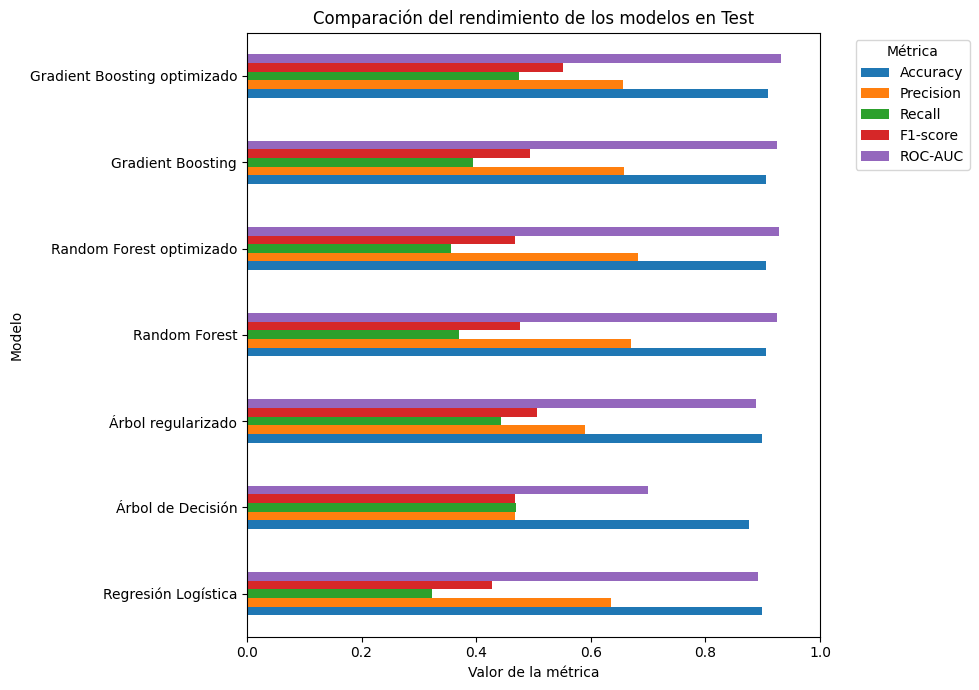

In [113]:
# Representación gráfica de las métricas en Test
ax = model_comparison.plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title("Comparación del rendimiento de los modelos en Test")
plt.xlabel("Valor de la métrica")
plt.ylabel("Modelo")
plt.xlim(0, 1)
plt.legend(title="Métrica", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

#### Conclusión de la comparación

La comparación gráfica confirma las diferencias observadas en la tabla de resultados. Los modelos de ensamblado presentan, en general, el mejor rendimiento, destacando Random Forest y Gradient Boosting.

Entre ellos, Gradient Boosting optimizado ofrece el mejor equilibrio global, al combinar el mayor ROC-AUC con valores superiores de `recall` y `F1-score`, manteniendo además un `accuracy` elevado.

### 10.3. Selección del modelo final

A partir de los resultados obtenidos, se selecciona **Gradient Boosting optimizado** como modelo final.

El modelo alcanza un ROC-AUC de 0.932, el valor más alto entre los modelos evaluados, junto con un `accuracy` de 0.910, un `recall` de 0.475 y un `F1-score` de 0.552.

Estos resultados muestran un buen equilibrio entre la capacidad general de discriminación y la identificación de la clase positiva, aspecto especialmente relevante debido al desbalance presente en la variable objetivo.

### 10.4. Matriz de confusión del modelo final

Para complementar la evaluación del modelo seleccionado, se analiza su matriz de confusión sobre el conjunto de Test. Esto permite observar directamente los aciertos y errores del modelo en cada una de las clases.

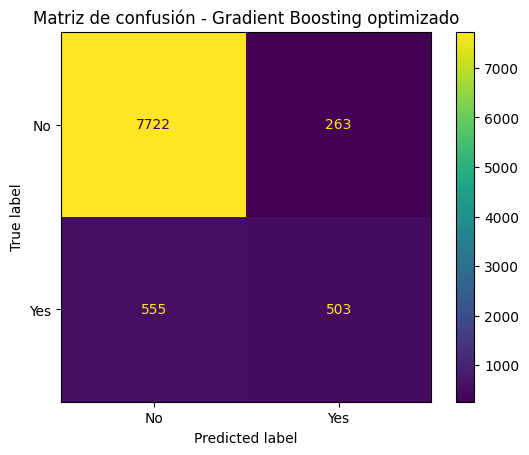

In [114]:
# Matriz de confusión del modelo final
cm_gb_opt = confusion_matrix(y_test, y_test_pred_gb_opt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_gb_opt,
    display_labels=["No", "Yes"]
)

disp.plot()
plt.title("Matriz de confusión - Gradient Boosting optimizado")
plt.show()

#### Conclusión de la matriz de confusión

La matriz de confusión muestra que el modelo clasifica correctamente 7.722 clientes que no contratan el depósito y 503 clientes que sí lo contratan.

El modelo presenta 263 falsos positivos y 555 falsos negativos. Por tanto, aunque mantiene una elevada capacidad para identificar la clase mayoritaria, todavía existe margen de mejora en la detección de los clientes que finalmente contratan.

Estos resultados son coherentes con el `recall` de 0.475 obtenido para la clase positiva y muestran una mejora en su detección respecto a la Regresión Logística utilizada como modelo de referencia.

### 10.5. Curva ROC del modelo final

Se representa la curva ROC del Gradient Boosting optimizado para analizar su capacidad de discriminación entre las clases a distintos umbrales de clasificación.

El área bajo la curva (ROC-AUC) resume esta capacidad: cuanto más próximo sea su valor a 1, mayor será la capacidad del modelo para diferenciar entre los clientes que contratan y los que no contratan el depósito.

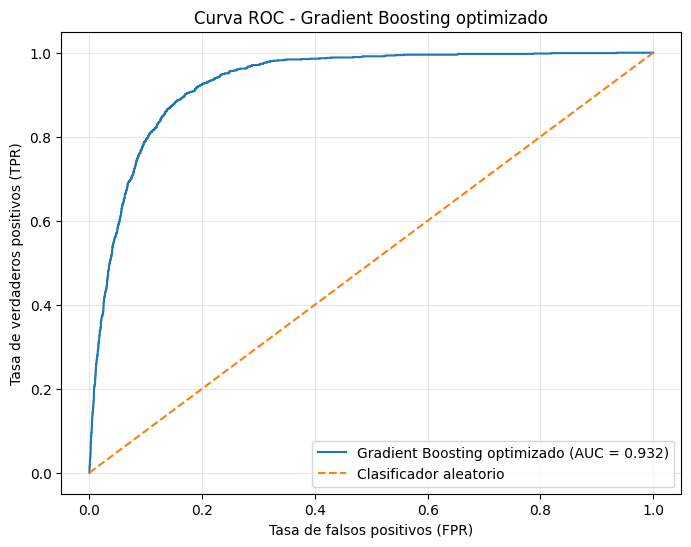

In [115]:
from sklearn.metrics import roc_curve

# Calculamos los puntos de la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba_gb_opt)

# Representamos la curva ROC
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Gradient Boosting optimizado (AUC = {metrics_test_gb_opt['ROC-AUC']:.3f})"
)

# Línea de referencia de un clasificador aleatorio
plt.plot([0, 1], [0, 1], linestyle="--", label="Clasificador aleatorio")

plt.xlabel("Tasa de falsos positivos (FPR)")
plt.ylabel("Tasa de verdaderos positivos (TPR)")
plt.title("Curva ROC - Gradient Boosting optimizado")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### Conclusión de la curva ROC

La curva ROC se mantiene claramente por encima de la línea correspondiente a un clasificador aleatorio y alcanza un área bajo la curva (ROC-AUC) de 0.932.

Este resultado confirma la buena capacidad del Gradient Boosting optimizado para discriminar entre los clientes que contratan el depósito y aquellos que no lo contratan a través de distintos umbrales de clasificación.

## 11. Conclusiones finales

A lo largo del análisis se prepararon y transformaron los datos con el objetivo de construir distintos modelos capaces de predecir si un cliente contratará o no un depósito bancario.

Durante la exploración se identificó un **desbalance en la variable objetivo**, con un 88,3 % de clientes que no contratan el depósito frente a un 11,7 % que sí lo hacen. Por este motivo, la evaluación de los modelos no se basó únicamente en `accuracy`, sino también en métricas como `precision`, `recall`, `F1-score` y ROC-AUC.

Se entrenaron y compararon diferentes algoritmos: Regresión Logística, Árbol de Decisión, Random Forest y Gradient Boosting. Además, se realizaron procesos de optimización de hiperparámetros mediante Grid Search y Random Search para mejorar el rendimiento y controlar posibles problemas de sobreajuste.

El **Gradient Boosting optimizado** presentó el mejor equilibrio global entre los modelos evaluados, alcanzando en Test un `accuracy` de 0.910, una `precision` de 0.657, un `recall` de 0.475, un `F1-score` de 0.552 y un ROC-AUC de 0.932.

La matriz de confusión muestra que el modelo identifica correctamente 503 de los 1.058 clientes que realmente contrataron el depósito. Aunque el resultado supone una mejora frente a otros modelos evaluados, los 555 falsos negativos indican que todavía existe margen de mejora en la identificación de la clase positiva.

En conjunto, el modelo presenta una buena capacidad de discriminación y generalización. Como posibles líneas de mejora, podrían estudiarse técnicas específicas para tratar el desbalance de clases y analizar diferentes umbrales de clasificación, buscando aumentar la detección de clientes potencialmente interesados sin incrementar excesivamente los falsos positivos.